In [1]:
import matplotlib.pyplot as plt
from skforecast.datasets import fetch_dataset

In [2]:
data = fetch_dataset(name = 'expenditures_australia')
data.index.name = 'datetime'

╭───────────────────────────── expenditures_australia ─────────────────────────────╮
│ Description:                                                                     │
│ Monthly expenditure on cafes, restaurants and takeaway food services in Victoria │
│ (Australia) from April 1982 up to April 2024.                                    │
│                                                                                  │
│ Source:                                                                          │
│ Australian Bureau of Statistics. Catalogue No. 8501.0                            │
│ https://www.abs.gov.au/statistics/industry/retail-and-wholesale-trade/retail-    │
│ trade-australia/apr-2024/8501011.xlsx                                            │
│                                                                                  │
│ URL:                                                                             │
│ https://raw.githubusercontent.com/skforecast/skforecast-                         │
│ datasets/refs/heads/main/data/expenditures_australia.csv                         │
│                                                                                  │
│ Shape: 505 rows x 1 columns                                                      │
╰──────────────────────────────────────────────────────────────────────────────────╯

In [3]:
data

,turnover
datetime,
1982-04-01,85.1
1982-05-01,85.1
1982-06-01,82.8
1982-07-01,82.1
1982-08-01,81.8
...,...
2023-12-01,1508.8
2024-01-01,1358.3
2024-02-01,1294.8


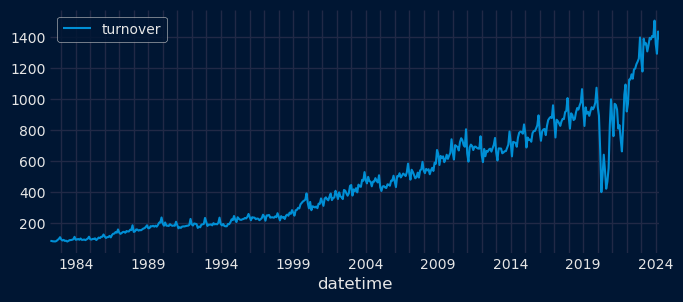

In [4]:
from skforecast.plot import set_dark_theme
set_dark_theme()
# **5. Exploracion de datos**
fig, ax = plt.subplots(figsize=(7, 3))
data.plot(ax=ax)
ax.legend()
plt.show()

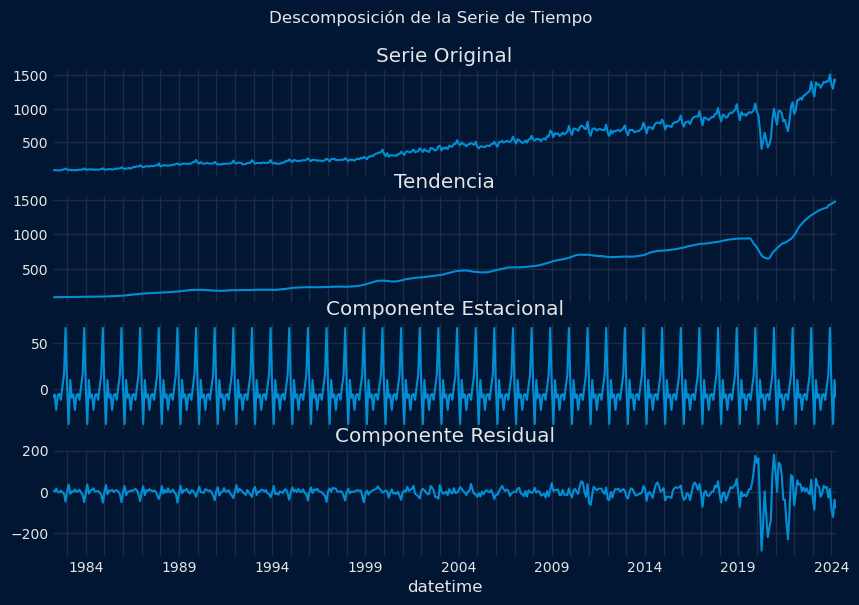

In [5]:
from statsmodels.tsa.seasonal import seasonal_decompose
res_descompose = seasonal_decompose(data['turnover'], model='additive', extrapolate_trend='freq')
fig, ax = plt.subplots(4, 1, figsize=(9, 6), sharex=True)
res_descompose.observed.plot(ax=ax[0])
ax[0].set_title('Serie Original')
res_descompose.trend.plot(ax=ax[1])
ax[1].set_title('Tendencia')
res_descompose.seasonal.plot(ax=ax[2])
ax[2].set_title('Componente Estacional')
res_descompose.resid.plot(ax=ax[3])
ax[3].set_title('Componente Residual')
fig.suptitle('Descomposición de la Serie de Tiempo')
plt.show()

C:\Users\USUARIO\AppData\Local\Temp\ipykernel_21524\475993690.py:2: FutureWarning: last is deprecated and will be removed in a future version. Please create a mask and filter using `.loc` instead
  data_last_10_years = data.last('10Y')
C:\Users\USUARIO\AppData\Local\Temp\ipykernel_21524\475993690.py:2: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  data_last_10_years = data.last('10Y')


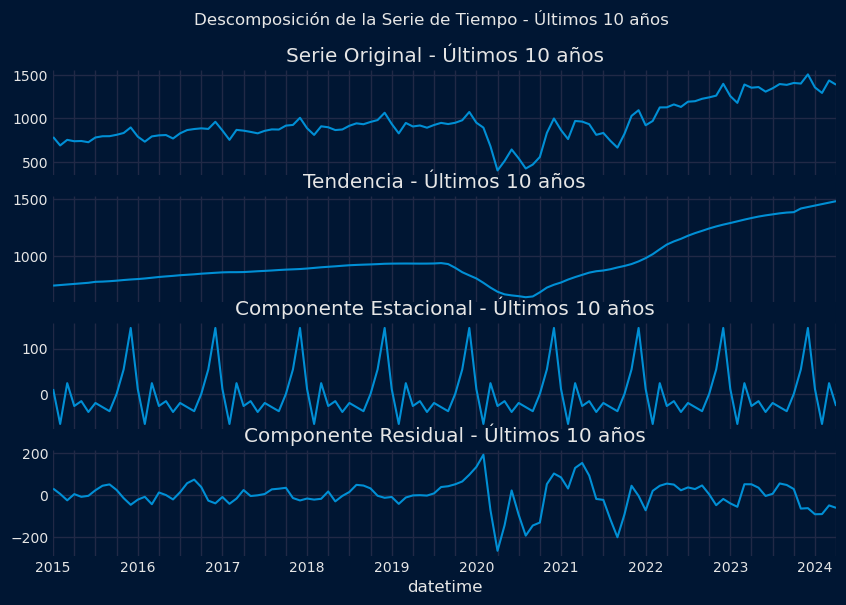

In [6]:
# grafico de solo los ultimos 10 anos con seasonal descompose 
data_last_10_years = data.last('10Y')
res_descompose_10y = seasonal_decompose(data_last_10_years['turnover'], model='additive', extrapolate_trend='freq')
fig, ax = plt.subplots(4, 1, figsize=(9, 6), sharex=True)
res_descompose_10y.observed.plot(ax=ax[0]) 
ax[0].set_title('Serie Original - Últimos 10 años')
res_descompose_10y.trend.plot(ax=ax[1])
ax[1].set_title('Tendencia - Últimos 10 años')
res_descompose_10y.seasonal.plot(ax=ax[2])
ax[2].set_title('Componente Estacional - Últimos 10 años')
res_descompose_10y.resid.plot(ax=ax[3])
ax[3].set_title('Componente Residual - Últimos 10 años')
fig.suptitle('Descomposición de la Serie de Tiempo - Últimos 10 años')
plt.show()

#### Etacionariedad:

Se puede ver claramente un patrón cada 12 meses, su varianza y covarianza se ven constantes, pero la media tiene una tendencia lineal, también hay residuos muy grandes en la pandemia los cuales solo afectan esos dos años de toda nuestra muestra, este rango de datos se deberá tratar 


In [7]:
#test de Dickey-Fuller
from statsmodels.tsa.stattools import adfuller
print('Test de Estacionariedad de Dickey-Fuller')
adfuller_result = adfuller(data['turnover'])
print(f'ADF Estadístico: {adfuller_result[0]}, p-value: {adfuller_result[1]}')

Test de Estacionariedad de Dickey-Fuller
ADF Estadístico: 1.188173570289818, p-value: 0.9959031465411221


No se cumple el test, diferenciaremos para eliminar la tendencia de la media 

Test de Estacionariedad
ADF Estadístico: -5.78262997466252, p-value: 5.084063177247745e-07


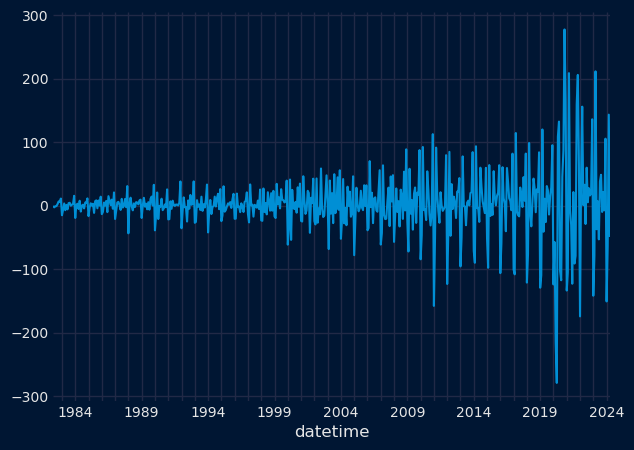

In [8]:
data_diff = data['turnover'].diff().dropna()
print('Test de Estacionariedad')
adfuller_result = adfuller(data_diff)
print(f'ADF Estadístico: {adfuller_result[0]}, p-value: {adfuller_result[1]}')
data_diff.plot()
plt.show()

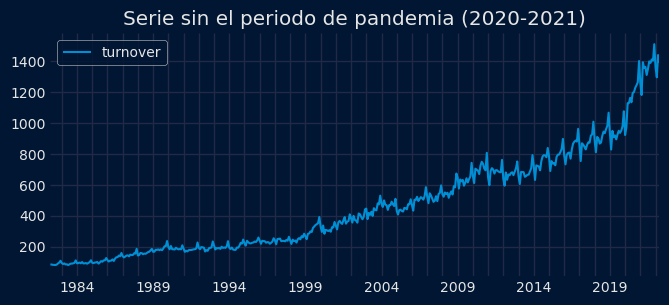

In [ ]:
import pandas as pd
# datos completos eliminando la pandemia
data_no_pandemic = data[(data.index < '2020-01-01') | (data.index > '2021-12-31')]
#pegamos los serie para que no tenga huecos

freq = pd.infer_freq(data.index)

data_no_pandemic.index = pd.date_range(
    start=data_no_pandemic.index.min(),
    periods=len(data_no_pandemic),
    freq=freq
)

#grafico sin pandemia
fig, ax = plt.subplots(figsize=(7, 3))
data_no_pandemic.plot(ax=ax)
ax.set_title('Serie sin el periodo de pandemia (2020-2021)')
ax.legend()
plt.show()





Test de Estacionariedad
ADF Estadístico: -4.776985423558576, p-value: 6.017588149152652e-05


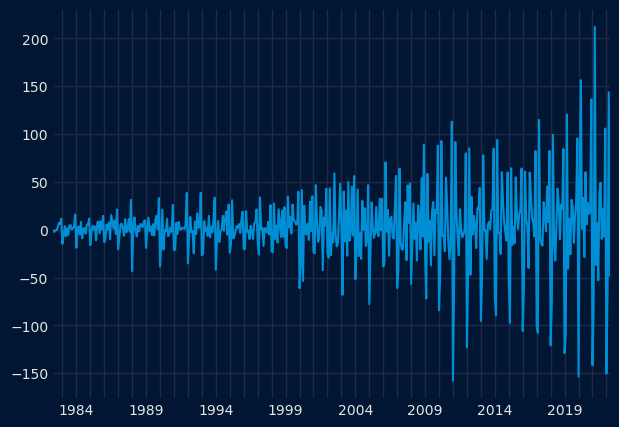

In [11]:
data_diff_NP = data_no_pandemic['turnover'].diff().dropna()
print('Test de Estacionariedad')
adfuller_result = adfuller(data_diff_NP)
print(f'ADF Estadístico: {adfuller_result[0]}, p-value: {adfuller_result[1]}')
data_diff_NP.plot()
plt.show()

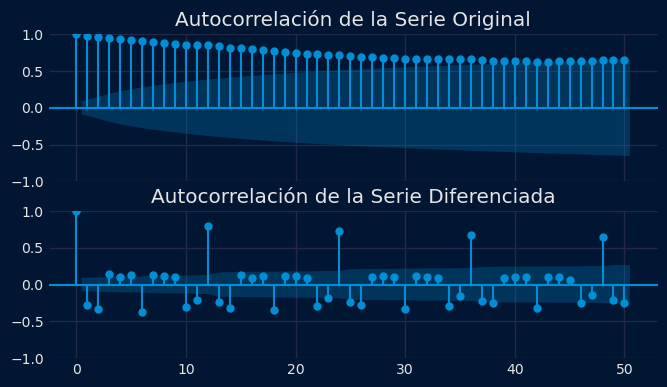

In [14]:
# graficos de correlacion y correlacion parcial
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
#Grafico de autocorrelacion
fig, ax = plt.subplots(2, 1, figsize=(7, 4), sharex=True)
plot_acf(data['turnover'], ax=ax[0], lags=50, alpha=0.05)
ax[0].set_title('Autocorrelación de la Serie Original')
plot_acf(data_diff_NP, ax=ax[1], lags=50, alpha=0.05)
ax[1].set_title('Autocorrelación de la Serie Diferenciada')
plt.show()

m = 12   
q = 3

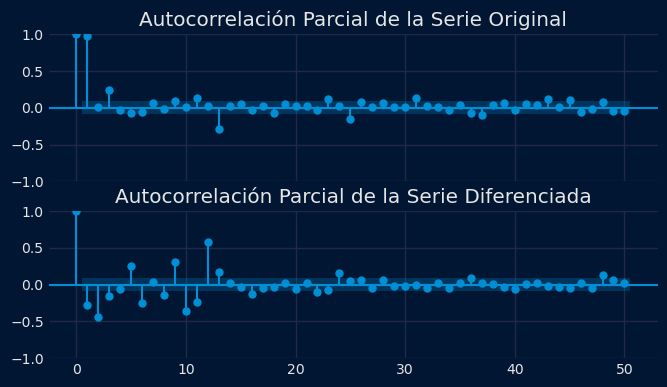

In [16]:
# graficos de correlacion y correlacion parcial
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
#Grafico de autocorrelacion parcial
fig, ax = plt.subplots(2, 1, figsize=(7, 4), sharex=True)
plot_pacf(data['turnover'], ax=ax[0], lags=50, alpha=0.05)
ax[0].set_title('Autocorrelación Parcial de la Serie Original')
plot_pacf(data_diff_NP, ax=ax[1], lags=50, alpha=0.05)
ax[1].set_title('Autocorrelación Parcial de la Serie Diferenciada')
plt.show()

p = 3 

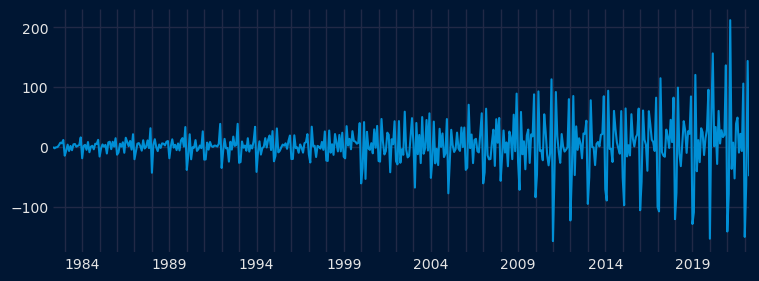

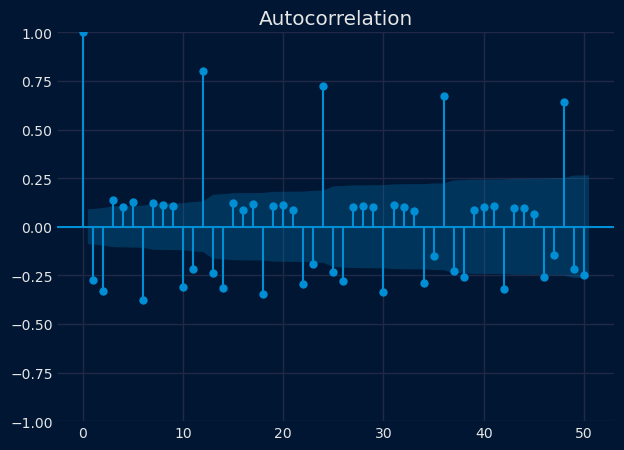

In [20]:
data_diff_NP.plot(figsize=(8,3))
from statsmodels.graphics.tsaplots import plot_acf
plot_acf(data_diff_NP, lags=50)
plt.show()

Se identifica que después de diferencias aún así se ve un patrón claro en la autocorrelación así que diferenciamos por el periodo 

In [21]:
#Diferenciacion de la serie estacional
data_diff_NP_12 = data_diff_NP.diff(12).dropna()
print('Test de Estacionariedad (Diferenciación Estacional)')
adfuller_result = adfuller(data_diff_NP_12)
print(f'ADF Estadístico (Diferenciación Estacional): {adfuller_result[0]}, p-value: {adfuller_result[1]}')

Test de Estacionariedad (Diferenciación Estacional)
ADF Estadístico (Diferenciación Estacional): -7.971601434822561, p-value: 2.7717585443384983e-12


Se cumple el test de adfuller luego de diferenciar una vez 
D = 1

<Figure size 700x300 with 0 Axes>

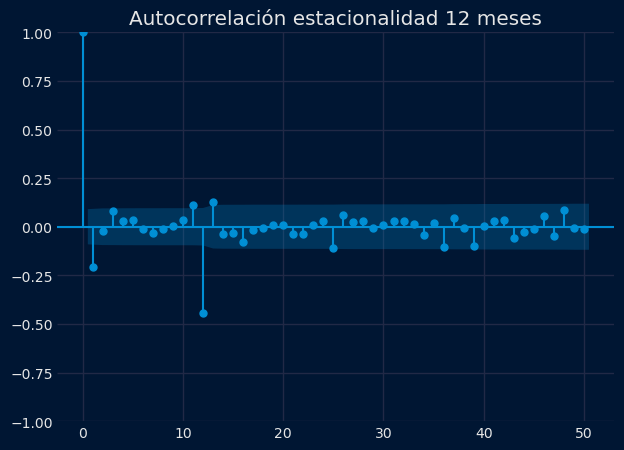

In [22]:
#Grafico de autocorrelacion de la serie estacionaria estacional
plt.figure(figsize=(7, 3))
plot_acf(data_diff_NP_12, lags=50, alpha=0.05)
plt.title('Autocorrelación estacionalidad 12 meses')
plt.show()  

Q = 1 

<Figure size 700x300 with 0 Axes>

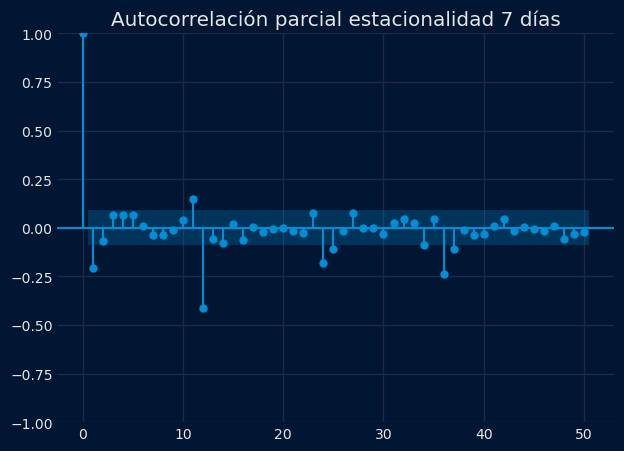

In [23]:
#Grafico de autocorrelacion de la serie estacionaria estacional
plt.figure(figsize=(7, 3))
plot_pacf(data_diff_NP_12, lags=50, alpha=0.05)
plt.title('Autocorrelación parcial estacionalidad 7 días')
plt.show()  

P = 1 

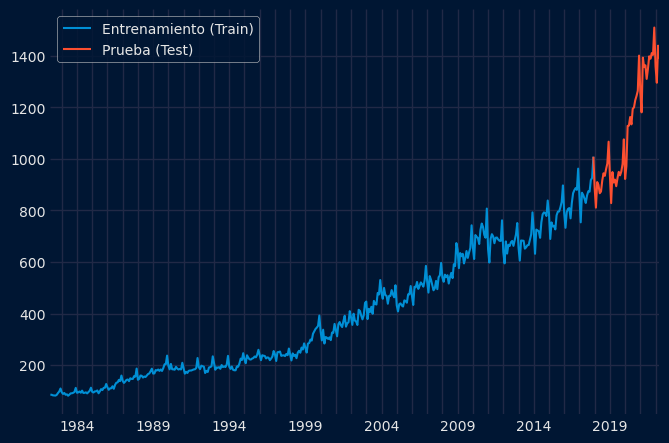

In [29]:
#Separar en datos de entrenamiento y prueba (70%-30%)
end_train = '2017-12-01'
data_train_NP = data_no_pandemic['turnover'].loc[:end_train]
data_test_NP = data_no_pandemic['turnover'].loc[end_train:]
plt.figure(figsize=(7, 5))
data_train_NP.plot(label='Entrenamiento (Train)')
data_test_NP.plot(label='Prueba (Test)')
plt.legend()
plt.show()

In [ ]:
data_train = data['turnover'].loc[:end_train]
data_test = data['turnover'].loc[end_train:]
plt.figure(figsize=(7, 5))
data_train.plot(label='Entrenamiento (Train)')
data_test.plot(label='Prueba (Test)')
plt.legend()
plt.show()

In [ ]:
# Sarimax
from statsmodels.tsa.statespace.sarimax import SARIMAX
modelo_sarimax = SARIMAX(endog = data_train, order = (3,1,3), seasonal_order=(1,1,1,12)) #p,d,q P,D,Q,S
modelo_sarimax = modelo_sarimax.fit(disp = 0)
modelo_sarimax.summary()

modelo_sarimax = SARIMAX(endog = data_train, order = (3,1,3), seasonal_order=(1,1,1,12)) #p,d,q P,D,Q,S
modelo_sarimax = modelo_sarimax.fit(disp = 0)
modelo_sarimax.summary()

c:\Users\USUARIO\anaconda3\envs\IA\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
c:\Users\USUARIO\anaconda3\envs\IA\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
c:\Users\USUARIO\anaconda3\envs\IA\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


<class 'statsmodels.iolib.summary.Summary'>
"""
                                      SARIMAX Results                                       
============================================================================================
Dep. Variable:                             turnover   No. Observations:                  429
Model:             SARIMAX(3, 1, 3)x(1, 1, [1], 12)   Log Likelihood               -1737.470
Date:                              Sun, 26 Oct 2025   AIC                           3492.940
Time:                                      10:54:54   BIC                           3529.216
Sample:                                  04-01-1982   HQIC                          3507.283
                                       - 12-01-2017                                         
Covariance Type:                                opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.3797      0.190      7.278      0.000       1.008       1.751
ar.L2         -1.0469      0.228     -4.593      0.000      -1.494      -0.600
ar.L3          0.4897      0.093      5.278      0.000       0.308       0.672
ma.L1         -1.6674      0.189     -8.811      0.000      -2.038      -1.296
ma.L2          1.3500      0.278      4.864      0.000       0.806       1.894
ma.L3         -0.6134      0.116     -5.274      0.000      -0.841      -0.385
ar.S.L12       0.1046      0.057      1.850      0.064      -0.006       0.215
ma.S.L12      -0.7178      0.044    -16.321      0.000      -0.804      -0.632
sigma2       245.0188     13.439     18.232      0.000     218.679     271.359
===================================================================================
Ljung-Box (L1) (Q):                   0.02   Jarque-Bera (JB):               158.35
Prob(Q):                              0.90   Prob(JB):                         0.00
Heteroskedasticity (H):               8.49   Skew:                            -0.43
Prob(H) (two-sided):                  0.00   Kurtosis:                         5.90
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [27]:
pred_sarimax = modelo_sarimax.get_forecast(steps=len(data_test)).predicted_mean
pred_sarimax.index = data_test.index
pred_sarimax.name = 'Predicciones SARIMAX'
display(pred_sarimax.head(4))

2017-12-01    914.564458
2018-01-01    833.895384
2018-02-01    921.834744
2018-03-01    912.432263
Freq: MS, Name: Predicciones SARIMAX, dtype: float64

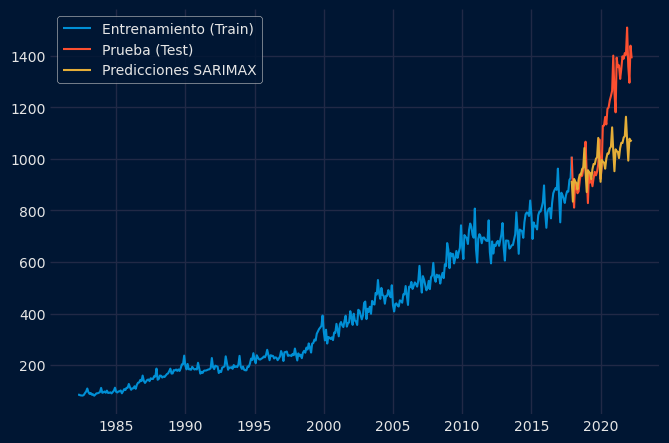

In [28]:
plt.figure(figsize=(7, 5))
plt.plot(data_train, label='Entrenamiento (Train)')
plt.plot(data_test, label='Prueba (Test)')
plt.plot(pred_sarimax, label='Predicciones SARIMAX')
plt.legend()
plt.show()

In [153]:
from sklearn.metrics import mean_absolute_percentage_error
mape_sarimax = mean_absolute_percentage_error(data_test, pred_sarimax)
print(f'MAPE SARIMAX: {mape_sarimax:.4f}')

MAPE SARIMAX: 0.7782


In [102]:
#Forecasting
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import MinMaxScaler
from skforecast.recursive import ForecasterRecursive
from skforecast.preprocessing import RollingFeatures
from skforecast.plot import plot_prediction_intervals

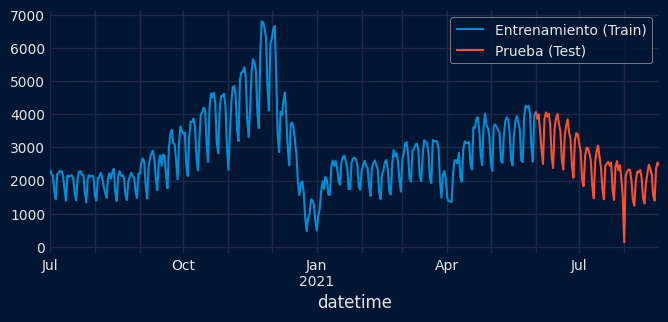

In [103]:
plt.figure(figsize=(7, 3))
data_train.plot(label='Entrenamiento (Train)')
data_test.plot(label='Prueba (Test)')
plt.legend()
plt.show()

In [104]:
forecaster_1 = ForecasterRecursive(regressor=LinearRegression(),
                                 lags=15, window_features=RollingFeatures(stats=['mean'], window_sizes=10))
forecaster_1.fit(y=data_train, store_in_sample_residuals=True)
forecaster_1

=================== 
ForecasterRecursive 
=================== 
Regressor: LinearRegression 
Lags: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15] 
Window features: ['roll_mean_10'] 
Window size: 15 
Series name: users 
Exogenous included: False 
Exogenous names: None 
Transformer for y: None 
Transformer for exog: None 
Weight function included: False 
Differentiation order: None 
Training range: [Timestamp('2020-07-01 00:00:00'), Timestamp('2021-06-01 00:00:00')] 
Training index type: DatetimeIndex 
Training index frequency: D 
Regressor parameters: 
    {'copy_X': True, 'fit_intercept': True, 'n_jobs': None, 'positive': False,
    'tol': 1e-06} 
fit_kwargs: {} 
Creation date: 2025-10-25 18:59:18 
Last fit date: 2025-10-25 18:59:18 
Skforecast version: 0.18.0 
Python version: 3.13.5 
Forecaster id: None

In [105]:
prediction_1 = forecaster_1.predict(steps=len(data_test))
prediction_1.index = data_test.index
prediction_1

datetime
2021-06-01    4017.442507
2021-06-02    3995.731833
2021-06-03    3696.578520
2021-06-04    2696.636991
2021-06-05    2473.091864
                 ...     
2021-08-21    2348.611064
2021-08-22    3045.215331
2021-08-23    3373.635315
2021-08-24    3342.827949
2021-08-25    3305.151629
Freq: D, Name: pred, Length: 86, dtype: float64

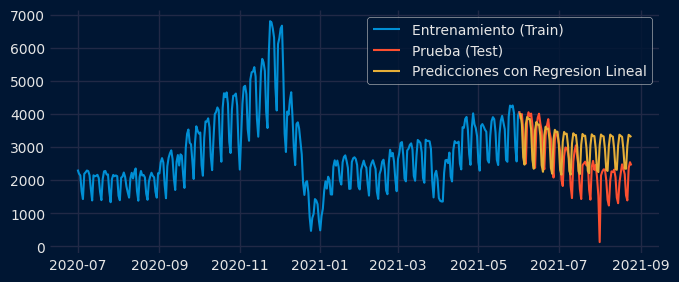

In [106]:
plt.figure(figsize=(7, 3))
plt.plot(data_train, label='Entrenamiento (Train)')
plt.plot(data_test, label='Prueba (Test)')
plt.plot(prediction_1, label='Predicciones con Regresion Lineal')
plt.legend()
plt.show()

In [107]:
mean_absolute_percentage_error(data_test, prediction_1)

0.5710334439534491

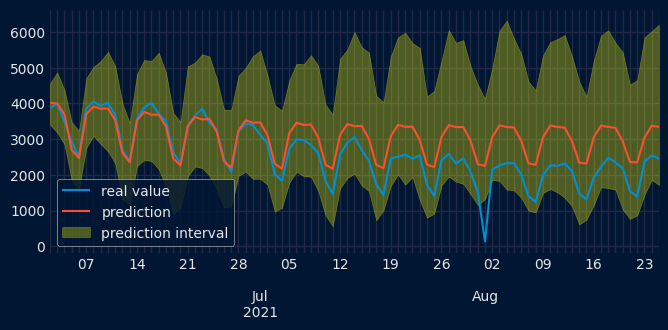

In [108]:
prediction_1_interval = forecaster_1.predict_interval(steps=len(data_test) -1,
                                                      interval=[5, 95],
                                                    method='bootstrapping', n_boot=100)
plot_prediction_intervals(predictions=prediction_1_interval, y_true=data_test, target_variable='users',
                          kwargs_fill_between={'color': 'yellow', 'alpha':0.3})
plt.show()

In [109]:
forecaster_2 = ForecasterRecursive(regressor=DecisionTreeRegressor(random_state=42),
                                 lags=15, window_features=RollingFeatures(stats=['mean'], window_sizes=10))
forecaster_2.fit(y=data_train, store_in_sample_residuals=True)
forecaster_2    

=================== 
ForecasterRecursive 
=================== 
Regressor: DecisionTreeRegressor 
Lags: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15] 
Window features: ['roll_mean_10'] 
Window size: 15 
Series name: users 
Exogenous included: False 
Exogenous names: None 
Transformer for y: None 
Transformer for exog: None 
Weight function included: False 
Differentiation order: None 
Training range: [Timestamp('2020-07-01 00:00:00'), Timestamp('2021-06-01 00:00:00')] 
Training index type: DatetimeIndex 
Training index frequency: D 
Regressor parameters: 
    {'ccp_alpha': 0.0, 'criterion': 'squared_error', 'max_depth': None,
    'max_features': None, 'max_leaf_nodes': None, 'min_impurity_decrease': 0.0,
    'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf':
    0.0, 'monotonic_cst': None, 'random_state': 42, 'splitter': 'best'} 
fit_kwargs: {} 
Creation date: 2025-10-25 18:59:19 
Last fit date: 2025-10-25 18:59:19 
Skforecast version: 0.18.0 
Python version: 3.13.5 
Forecaster id: None

In [110]:
prediction_2 = forecaster_2.predict(steps=len(data_test))
prediction_2

2021-06-02    2781.0
2021-06-03    3579.0
2021-06-04    2781.0
2021-06-05    1931.0
2021-06-06    1558.0
               ...  
2021-08-22    1635.0
2021-08-23    2101.0
2021-08-24    2144.0
2021-08-25    2235.0
2021-08-26    2178.0
Freq: D, Name: pred, Length: 86, dtype: float64

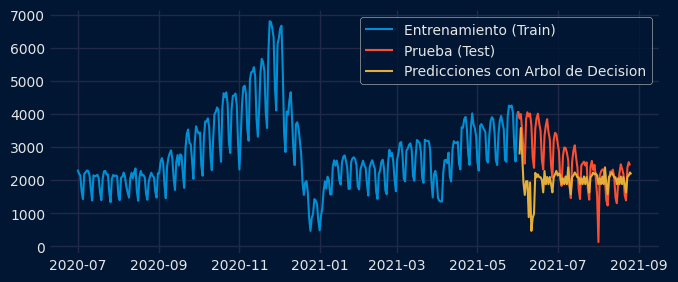

In [111]:
plt.figure(figsize=(7, 3))
plt.plot(data_train, label='Entrenamiento (Train)')
plt.plot(data_test, label='Prueba (Test)')
plt.plot(prediction_2, label='Predicciones con Arbol de Decision')
plt.legend()
plt.show()

In [112]:
mean_absolute_percentage_error(data_test, prediction_2)

0.4291034497644619

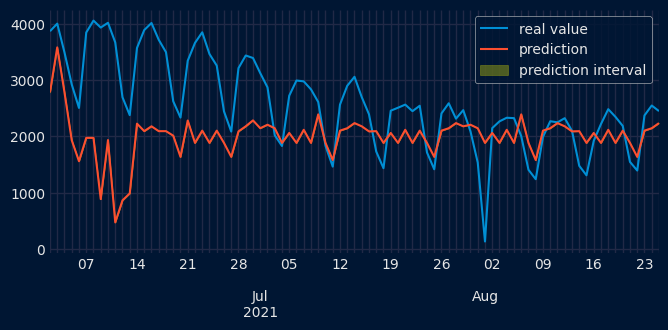

In [113]:
prediction_2_interval = forecaster_2.predict_interval(steps=len(data_test) -1,
                                                      interval=[5, 95],
                                                    method='bootstrapping', n_boot=100)
plot_prediction_intervals(predictions=prediction_2_interval, y_true=data_test, target_variable='users',
                          kwargs_fill_between={'color': 'yellow', 'alpha':0.3})
plt.show()

In [114]:
from skforecast.model_selection import grid_search_forecaster, random_search_forecaster, TimeSeriesFold
forecaster_3 = ForecasterRecursive(
    regressor = RandomForestRegressor(random_state = 42),
    lags = 10
)

# Busqueda de la ventana
lags_grid = {'lags_1':3, 'lags_2':10, 'lags_3':[1,2,3,7]} # Cada 7 periodos hay un evento que se repite

# Busqueda de hiperparametros del regresor
param_grid = {'max_depth':[5, 10, 20], 'criterion':['squared_error', 'poisson', 'absolute_error', 'friedman_mse']}

# Folds
cv = TimeSeriesFold(
    steps = 7,
    initial_train_size = len(data_test),
    refit = False
)

# Implementacion de la busqueda de hiperparametros
result = grid_search_forecaster(
    forecaster = forecaster_3,
    y = data_train,
    param_grid = param_grid,
    lags_grid = lags_grid,
    cv = cv,
    metric = 'mean_squared_error',
    return_best = True,
    n_jobs = 1,
    verbose = False,
    show_progress = True
)

result

lags grid: 100%|██████████| 3/3 [00:45<00:00, 15.28s/it]


`Forecaster` refitted using the best-found lags and parameters, and the whole data set: 
  Lags: [ 1  2  3  4  5  6  7  8  9 10] 
  Parameters: {'criterion': 'absolute_error', 'max_depth': 10}
  Backtesting metric: 1066788.7140886


,lags,lags_label,params,mean_squared_error,criterion,max_depth
0,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]",lags_2,"{'criterion': 'absolute_error', 'max_depth': 10}",1.066789e+06,absolute_error,10
1,"[1, 2, 3, 7]",lags_3,"{'criterion': 'absolute_error', 'max_depth': 10}",1.073058e+06,absolute_error,10
2,"[1, 2, 3, 7]",lags_3,"{'criterion': 'poisson', 'max_depth': 10}",1.078948e+06,poisson,10
3,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]",lags_2,"{'criterion': 'absolute_error', 'max_depth': 5}",1.079536e+06,absolute_error,5
4,"[1, 2, 3, 7]",lags_3,"{'criterion': 'squared_error', 'max_depth': 10}",1.080293e+06,squared_error,10
5,"[1, 2, 3, 7]",lags_3,"{'criterion': 'friedman_mse', 'max_depth': 10}",1.080293e+06,friedman_mse,10
6,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]",lags_2,"{'criterion': 'friedman_mse', 'max_depth': 5}",1.083101e+06,friedman_mse,5
7,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]",lags_2,"{'criterion': 'squared_error', 'max_depth': 5}",1.083101e+06,squared_error,5
8,"[1, 2, 3, 7]",lags_3,"{'criterion': 'absolute_error', 'max_depth': 5}",1.085122e+06,absolute_error,5
9,"[1, 2, 3, 7]",lags_3,"{'criterion': 'squared_error', 'max_depth': 5}",1.085897e+06,squared_error,5


In [115]:
forecaster_3

=================== 
ForecasterRecursive 
=================== 
Regressor: RandomForestRegressor 
Lags: [ 1  2  3  4  5  6  7  8  9 10] 
Window features: None 
Window size: 10 
Series name: users 
Exogenous included: False 
Exogenous names: None 
Transformer for y: None 
Transformer for exog: None 
Weight function included: False 
Differentiation order: None 
Training range: [Timestamp('2020-07-01 00:00:00'), Timestamp('2021-06-01 00:00:00')] 
Training index type: DatetimeIndex 
Training index frequency: D 
Regressor parameters: 
    {'bootstrap': True, 'ccp_alpha': 0.0, 'criterion': 'absolute_error',
    'max_depth': 10, 'max_features': 1.0, 'max_leaf_nodes': None, 'max_samples':
    None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1,
    'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst':
    None, 'n_estimators': 100, 'n_jobs': None, 'oob_score': False,
    'random_state': 42, 'verbose': 0, 'warm_start': False} 
fit_kwargs: {} 
Creation date: 2025-10-25 18:59:21 
Last fit date: 2025-10-25 19:00:08 
Skforecast version: 0.18.0 
Python version: 3.13.5 
Forecaster id: None

In [116]:
prediction_3 = forecaster_3.predict(steps=len(data_test))
prediction_3

2021-06-02    4332.835
2021-06-03    4550.400
2021-06-04    4269.835
2021-06-05    3125.625
2021-06-06    2698.885
                ...   
2021-08-22    4104.755
2021-08-23    4037.515
2021-08-24    4054.455
2021-08-25    4391.340
2021-08-26    4605.185
Freq: D, Name: pred, Length: 86, dtype: float64

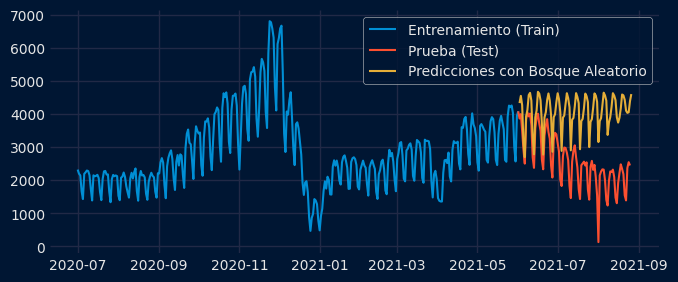

In [117]:
plt.figure(figsize=(7, 3))
plt.plot(data_train, label='Entrenamiento (Train)')
plt.plot(data_test, label='Prueba (Test)')
plt.plot(prediction_3, label='Predicciones con Bosque Aleatorio')
plt.legend()
plt.show()

In [118]:
mean_absolute_percentage_error(data_test, prediction_3)

0.9936469175870449

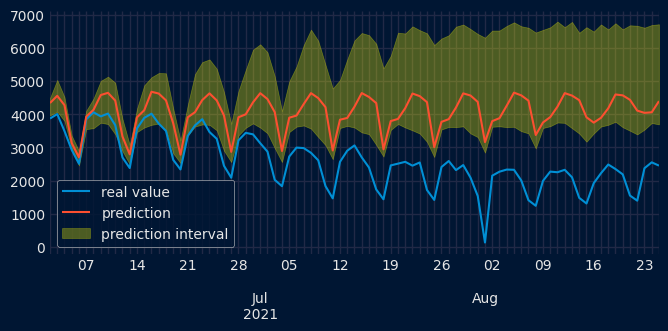

In [119]:
prediction_3_interval = forecaster_3.predict_interval(steps=len(data_test) -1,
                                                      interval=[5, 95],
                                                    method='bootstrapping', n_boot=100)
plot_prediction_intervals(predictions=prediction_3_interval, y_true=data_test, target_variable='users',
                          kwargs_fill_between={'color': 'yellow', 'alpha':0.3})
plt.show()

# Redes Neuronales

In [120]:
#Redes neuronales artificiales

from skforecast.deep_learning import ForecasterRnn, create_and_compile_model
from keras.optimizers import Adam
from keras.losses import MeanSquaredError
from keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.preprocessing import MinMaxScaler

In [121]:
model_rna = create_and_compile_model(series=pd.DataFrame(data_train),
                                     levels=['users'], lags=24, steps=1, recurrent_layer='RNN', recurrent_units=100, dense_units=64)
model_rna.summary()

keras version: 3.11.3
Using backend: tensorflow
tensorflow version: 2.20.0



Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ series_input (InputLayer)       │ (None, 24, 1)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rnn_1 (SimpleRNN)               │ (None, 100)            │        10,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         6,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_dense_td_layer (Dense)   │ (None, 1)              │            65 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 1, 1)           │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,729 (65.35 KB)

 Trainable params: 16,729 (65.35 KB)

 Non-trainable params: 0 (0.00 B)

In [122]:
forecaster_4 = ForecasterRnn(regressor=model_rna,
                             levels=['users'],
                             lags=24,
                             transformer_series=MinMaxScaler(),
                             fit_kwargs={
                                 'epochs':25,
                                 'batch_size':512,
                                 'callbacks':[EarlyStopping(monitor='val_loss', restore_best_weights=True)],
                                 'series_val': pd.DataFrame(data_test)})
forecaster_4.fit(pd.DataFrame(data_train))
forecaster_4


c:\Users\Asus\Desktop\EIA 2025-2\ComputacionCientifica\cientifica\Lib\site-packages\keras\src\saving\saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 16 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Epoch 1/25
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - loss: 0.0430WARNING:tensorflow:5 out of the last 15 calls to <function TensorFlowTrainer._make_function.<locals>.multi_step_on_iterator at 0x000001AEEA5E5760> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step - loss: 0.0430 - val_loss: 0.2200
Epoch 2/25
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 325ms/step - loss: 0.1716 - val_loss: 0.0519
Epoch 3/25
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 321ms/step - loss: 0.0390 - val_

============= 
ForecasterRnn 
============= 
Regressor: <Functional name=functional_1, built=True> 
Layers names: ['series_input', 'rnn_1', 'dense_1', 'output_dense_td_layer', 'reshape'] 
Lags: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24] 
Window size: 24 
Maximum steps to predict: [1] 
Series names: users 
Target series (levels): ['users'] 
Exogenous included: False 
Exogenous names: None 
Transformer for series: MinMaxScaler() 
Transformer for exog: MinMaxScaler() 
Training range: [Timestamp('2020-07-01 00:00:00'), Timestamp('2021-06-01 00:00:00')] 
Training index type: DatetimeIndex 
Training index frequency: D 
Regressor parameters: {'name': 'functional_1', 'trainable': True, 'layers': [{'module': 'keras.layers', 'class_name': 'InputLayer', 'config': {'batch_shape': (None, 24, 1), 'dtype': 'float32', 'sparse': False, 'ragged': False, 'name': 'series_input'}, 'registered_name': None, 'name': 'series_input', 'inbound_nodes': []}, {'module': 'keras.layers', 'class_name': 'SimpleRNN', 'config': {'name': 'rnn_1', 'trainable': True, 'dtype': {'module': 'keras', 'class_name': 'DTypePolicy', 'config': {'name': 'float32'}, 'registered_name': None}, 'return_sequences': False, 'return_state': False, 'go_backwards': False, 'stateful': False, 'unroll': False, 'zero_output_for_mask': False, 'units': 100, 'activation': 'tanh', 'use_bias': True, 'kernel_initializer': {'module': 'keras.initializers', 'class_name': 'GlorotUniform', 'config': {'seed': None}, 'registered_name': None}, 'recurrent_initializer': {'module': 'keras.initializers', 'class_name': 'Orthogonal', 'config': {'seed': None, 'gain': 1.0}, 'registered_name': None}, 'bias_initializer': {'module': 'keras.initializers', 'class_name': 'Zeros', 'config': {}, 'registered_name': None}, 'kernel_regularizer': None, 'recurrent_regularizer': None, 'bias_regularizer': None, 'activity_regularizer': None, 'kernel_constraint': None, 'recurrent_constraint': None, 'bias_constraint': None, 'dropout': 0.0, 'recurrent_dropout': 0.0}, 'registered_name': None, 'build_config': {'input_shape': [None, 24, 1]}, 'name': 'rnn_1', 'inbound_nodes': [{'args': ({'class_name': '__keras_tensor__', 'config': {'shape': (None, 24, 1), 'dtype': 'float32', 'keras_history': ['series_input', 0, 0]}},), 'kwargs': {'training': False, 'mask': None}}]}, {'module': 'keras.layers', 'class_name': 'Dense', 'config': {'name': 'dense_1', 'trainable': True, 'dtype': {'module': 'keras', 'class_name': 'DTypePolicy', 'config': {'name': 'float32'}, 'registered_name': None}, 'units': 64, 'activation': 'relu', 'use_bias': True, 'kernel_initializer': {'module': 'keras.initializers', 'class_name': 'GlorotUniform', 'config': {'seed': None}, 'registered_name': None}, 'bias_initializer': {'module': 'keras.initializers', 'class_name': 'Zeros', 'config': {}, 'registered_name': None}, 'kernel_regularizer': None, 'bias_regularizer': None, 'kernel_constraint': None, 'bias_constraint': None}, 'registered_name': None, 'build_config': {'input_shape': [None, 100]}, 'name': 'dense_1', 'inbound_nodes': [{'args': ({'class_name': '__keras_tensor__', 'config': {'shape': (None, 100), 'dtype': 'float32', 'keras_history': ['rnn_1', 0, 0]}},), 'kwargs': {}}]}, {'module': 'keras.layers', 'class_name': 'Dense', 'config': {'name': 'output_dense_td_layer', 'trainable': True, 'dtype': {'module': 'keras', 'class_name': 'DTypePolicy', 'config': {'name': 'float32'}, 'registered_name': None}, 'units': 1, 'activation': 'linear', 'use_bias': True, 'kernel_initializer': {'module': 'keras.initializers', 'class_name': 'GlorotUniform', 'config': {'seed': None}, 'registered_name': None}, 'bias_initializer': {'module': 'keras.initializers', 'class_name': 'Zeros', 'config': {}, 'registered_name': None}, 'kernel_regularizer': None, 'bias_regularizer': None, 'kernel_constraint': None, 'bias_constraint': None}, 'registered_name': None, 'build_config': {'input_shape': [None, 64]}, 'name': 'output_dense_td_layer', 'inbound_nodes': [{'args': ({'clas

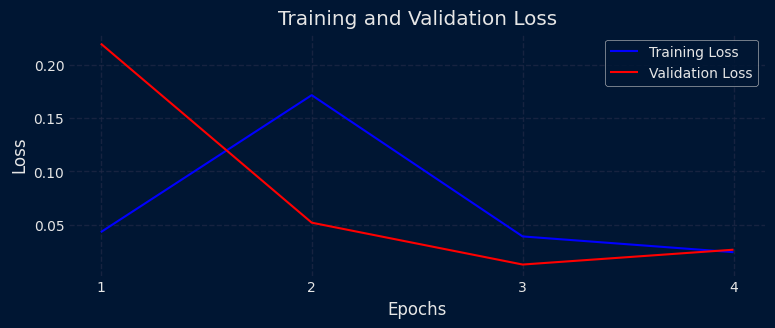

In [123]:
fig, ax = plt.subplots(figsize=(8, 3))
plot = forecaster_4.plot_history(ax=ax)

In [124]:
from skforecast.model_selection import backtesting_forecaster_multiseries
cv = TimeSeriesFold(
    steps = forecaster_4.max_step,
    initial_train_size = len(data_test),
    refit = False
)
metrics, prediction_4 = backtesting_forecaster_multiseries(forecaster=forecaster_4,
                                              series=pd.DataFrame(data_train),
                                              cv=cv,
                                              levels = forecaster_4.levels,
                                              metric = 'mean_squared_error', verbose=False)

Epoch 1/25
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - loss: 0.0532WARNING:tensorflow:5 out of the last 13 calls to <function TensorFlowTrainer._make_function.<locals>.multi_step_on_iterator at 0x000001AEEAAFB240> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step - loss: 0.0532 - val_loss: 0.0752
Epoch 2/25
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 354ms/step - loss: 0.0527 - val_loss: 0.0617


100%|██████████| 250/250 [01:05<00:00,  3.84it/s]


In [125]:
metrics

,levels,mean_squared_error
0,users,1287553.875


In [126]:
prediction_4

,level,fold,pred
2020-09-25,users,0,2467.990723
2020-09-26,users,1,2366.454102
2020-09-27,users,2,2494.565430
2020-09-28,users,3,2224.500488
2020-09-29,users,4,2377.300537
...,...,...,...
2021-05-28,users,245,2769.569336
2021-05-29,users,246,2759.203125
2021-05-30,users,247,2707.966309
2021-05-31,users,248,2601.761475


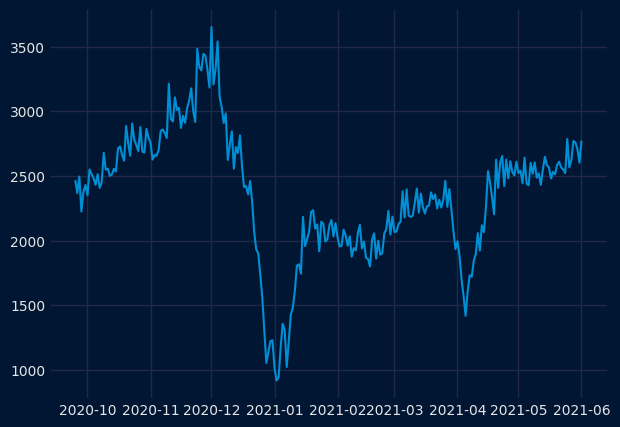

In [127]:
plt.plot(prediction_4['pred'])